<a href="https://colab.research.google.com/github/Hami-611/Insurance_Premium_Prediction/blob/main/Insurance_premium_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [2]:
df = pd.read_csv("/insurance.csv")

In [3]:
df.head()

,age,sex,bmi,children,smoker,region,expenses
0,19,female,27.9,0,yes,southwest,16884.92
1,18,male,33.8,1,no,southeast,1725.55
2,28,male,33.0,3,no,southeast,4449.46
3,33,male,22.7,0,no,northwest,21984.47
4,32,male,28.9,0,no,northwest,3866.86


In [5]:
df.shape

(1338, 7)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   expenses  1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [8]:
df.describe(include='all')

,age,sex,bmi,children,smoker,region,expenses
count,1338.000000,1338,1338.000000,1338.000000,1338,1338,1338.000000
unique,NaN,2,NaN,NaN,2,4,NaN
top,NaN,male,NaN,NaN,no,southeast,NaN
freq,NaN,676,NaN,NaN,1064,364,NaN
mean,39.207025,NaN,30.665471,1.094918,NaN,NaN,13270.422414
std,14.049960,NaN,6.098382,1.205493,NaN,NaN,12110.011240
min,18.000000,NaN,16.000000,0.000000,NaN,NaN,1121.870000
25%,27.000000,NaN,26.300000,0.000000,NaN,NaN,4740.287500
50%,39.000000,NaN,30.400000,1.000000,NaN,NaN,9382.030000
75%,51.000000,NaN,34.700000,2.000000,NaN,NaN,16639.915000


In [10]:
df.drop_duplicates()

,age,sex,bmi,children,smoker,region,expenses
0,19,female,27.9,0,yes,southwest,16884.92
1,18,male,33.8,1,no,southeast,1725.55
2,28,male,33.0,3,no,southeast,4449.46
3,33,male,22.7,0,no,northwest,21984.47
4,32,male,28.9,0,no,northwest,3866.86
...,...,...,...,...,...,...,...
1333,50,male,31.0,3,no,northwest,10600.55
1334,18,female,31.9,0,no,northeast,2205.98
1335,18,female,36.9,0,no,southeast,1629.83
1336,21,female,25.8,0,no,southwest,2007.95


Data Analysis

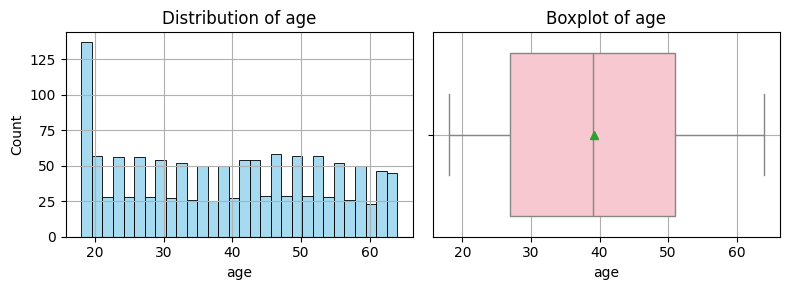

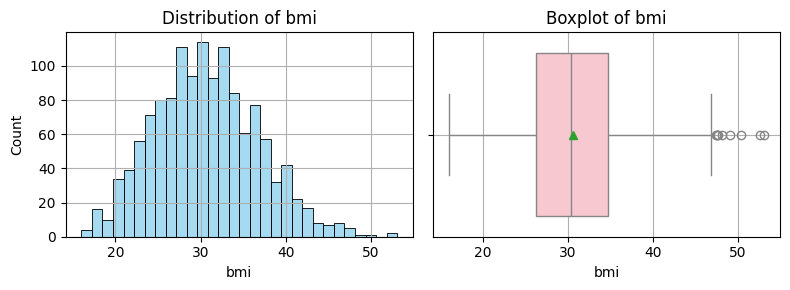

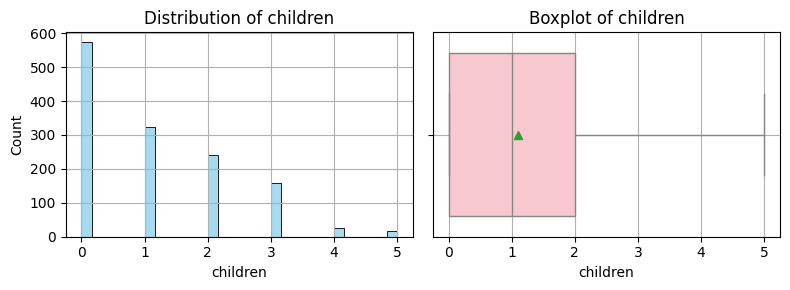

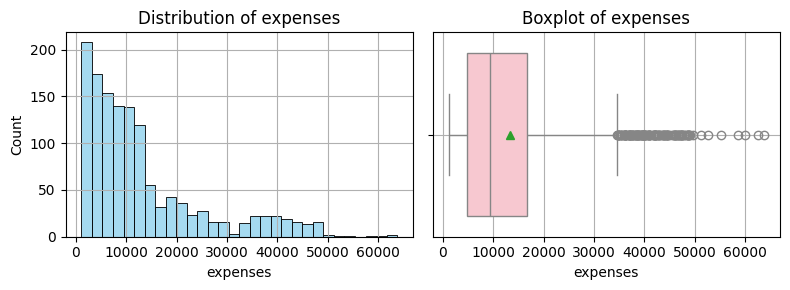

In [17]:
x_axis = ['age', 'bmi', 'children', 'expenses']

for x in x_axis:
    fig, axes = plt.subplots(1, 2, figsize=(8, 3))

    # Histogram
    sns.histplot(df[x], ax=axes[0], kde=False, color='skyblue', bins=30)
    axes[0].set_title(f'Distribution of {x}')
    axes[0].grid(True)

    # Boxplot
    sns.boxplot(x=df[x], ax=axes[1], orient="h", showmeans=True, color='pink')
    axes[1].set_title(f'Boxplot of {x}')
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

Handle categorical columns

In [20]:
df.sex.unique()

array(['female', 'male'], dtype=object)

In [21]:
df['sex'] = df.sex.map({'female': 0,'male':1})

In [23]:
df.smoker.unique()

array(['yes', 'no'], dtype=object)

In [24]:
df['smoker'] = df.smoker.map({'yes':1,'no': 0})

In [25]:
df['region'] = df.region.map({'southwest': 1,'southeast':2,'northwest':3 ,'northeast':4 })

In [26]:
df.head()

,age,sex,bmi,children,smoker,region,expenses
0,19,0,27.9,0,1,1,16884.92
1,18,1,33.8,1,0,2,1725.55
2,28,1,33.0,3,0,2,4449.46
3,33,1,22.7,0,0,3,21984.47
4,32,1,28.9,0,0,3,3866.86


Split the dataset

In [27]:
x = df.drop(['expenses'],axis=1)

In [32]:
x.head()

,age,sex,bmi,children,smoker,region
0,19,0,27.9,0,1,1
1,18,1,33.8,1,0,2
2,28,1,33.0,3,0,2
3,33,1,22.7,0,0,3
4,32,1,28.9,0,0,3


In [30]:
y = df[['expenses']]

In [31]:
y.head()

,expenses
0,16884.92
1,1725.55
2,4449.46
3,21984.47
4,3866.86


In [34]:
from sklearn.model_selection import train_test_split

In [63]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [64]:
x_train.shape

(1070, 6)

In [65]:
x_test.shape

(268, 6)

Model Training


Random Forest Regressor

In [82]:
from sklearn.ensemble import RandomForestRegressor

In [83]:
model = RandomForestRegressor()

In [84]:
model.fit(x_train, y_train)

/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForestRegressor()

In [85]:
y_pred = model.predict(x_test)

In [86]:
from sklearn.metrics import r2_score
score = r2_score(y_test,y_pred)
score

0.8647013051540736

Predict charges in new customer

In [87]:
data = {
    'age': 40,
    'sex': 1,
    'bmi': 40,
    'children': 3,
    'smoker': 1,
    'region': 2
}

new_df = pd.DataFrame(data, index=[0])
new_df

,age,sex,bmi,children,smoker,region
0,40,1,40,3,1,2


In [89]:
pred = model.predict(new_df)
pred[0]

np.float64(42313.72960000006)

In [90]:
import joblib
joblib.dump(model, 'random_forest_regression')

['random_forest_regression']